# Preposicao

Pergunta: Como as proposições legislativas abordam os impactos ambientais da inteligência artificial e da infraestrutura digital entre 2023 e 2025?


## Metodologia
A pesquisa consulta a API de Dados Abertos da Câmara e coleta ementas de PL, PLP, PEC e MPV apresentadas entre 2023 e 2025.

Na limpeza, são removidos registros sem informações essenciais e duplicados; depois, são selecionadas ementas que mencionam tecnologia e meio ambiente.

O TF-IDF destaca os termos mais relevantes dos textos selecionados, enquanto o GPT classifica a relação ambiental como direta, indireta, ausente ou incerta e registra uma evidência literal.

A validação acompanha a quantidade de registros em cada etapa, confere as evidências do GPT e apresenta as limitações de usar ementas e seleção por palavras-chave.


## Dependências
Instala as bibliotecas do projeto


In [1]:
%pip install -q requests==2.34.2 pandas==2.3.3 openai==3.13.0 python-dotenv==1.2.3 pydantic==2.13.5 matplotlib==3.10.9 scikit-learn==1.7.2


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Imports
Carrega as bibliotecas do projeto.


In [2]:
import os
from getpass import getpass
from datetime import datetime, timezone
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import requests
from dotenv import load_dotenv
from IPython.display import Markdown, display
from openai import OpenAI
from pydantic import BaseModel
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

## Configuração

Define as variáveis de ambiente

In [3]:
ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
load_dotenv(ROOT / ".env", override=True)
OPENAI_API_KEY_VALUE = os.getenv("OPENAI_API_KEY", "").strip()
if not OPENAI_API_KEY_VALUE:
    OPENAI_API_KEY_VALUE = getpass("OPENAI_API_KEY: ")

OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4.1-mini").strip()

OPENAI_PARAMETERS = {"temperature": 0, "max_output_tokens": 500, "store": False}
START, END = "2023-01-01", "2025-12-31"
TYPES = ["PL", "PLP", "PEC", "MPV"]
CAMARA_API_URL = "https://dadosabertos.camara.leg.br/api/v2/proposicoes"
STAGES = ROOT / "outputs"
OPENAI_CLIENT = OpenAI(api_key=OPENAI_API_KEY_VALUE, timeout=60, max_retries=3)

## 01 Coleta
Consulta a API da Câmara em períodos de até três meses e percorre todas as páginas retornadas. Salva os dados brutos para a próxima etapa.


In [4]:
CAMARA_SESSION = requests.Session()
CAMARA_SESSION.mount("https://", HTTPAdapter(max_retries=Retry(total=3, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])))

records = []
pages = 0
start = pd.Timestamp(START)

while start <= pd.Timestamp(END):
    finish = min(start + pd.DateOffset(months=3) - pd.Timedelta(days=1), pd.Timestamp(END))
    params = {
        "siglaTipo": ",".join(TYPES),
        "dataApresentacaoInicio": start.strftime("%Y-%m-%d"),
        "dataApresentacaoFim": finish.strftime("%Y-%m-%d"),
        "itens": 100
    }
    url = requests.Request("GET", CAMARA_API_URL, params=params).prepare().url

    while url:
        camara_response = CAMARA_SESSION.get(url, timeout=60)
        camara_response.raise_for_status()
        page = camara_response.json()
        pages += 1
        records.extend(page["dados"])
        url = next((link["href"] for link in page["links"] if link["rel"] == "next"), None)

    start = finish + pd.Timedelta(days=1)

CAMARA_SESSION.close()
raw = pd.DataFrame(records)
STAGES.joinpath("01_coleta").mkdir(parents=True, exist_ok=True)
raw.to_csv(STAGES / "01_coleta" / "proposicoes_brutas.csv", index=False, encoding="utf-8-sig")

display(pd.Series({
    "Período": f"{START} a {END}",
    "Páginas": pages,
    "Registros recebidos": len(raw)
}, name="Coleta"))

Período                2023-01-01 a 2025-12-31
Páginas                                    181
Registros recebidos                      17516
Name: Coleta, dtype: object

## 02 Limpeza
Carrega os dados brutos, mantém as colunas usadas na pesquisa e remove registros sem informações essenciais ou repetidos. Depois, seleciona ementas que mencionam tecnologia e meio ambiente e salva os candidatos para o GPT.


In [5]:
raw = pd.read_csv(STAGES / "01_coleta" / "proposicoes_brutas.csv")
colunas = ["id", "siglaTipo", "numero", "ano", "dataApresentacao", "ementa", "uri"]
base = raw[colunas].copy()
base["date"] = pd.to_datetime(base["dataApresentacao"], errors="coerce")
base = base.dropna(subset=["id", "siglaTipo", "date", "ementa"])
base = base[base["siglaTipo"].isin(TYPES)]
base = base[base["date"].between(START, END)]
base = base.drop_duplicates("id")


Seleciona as ementas que combinam termos de tecnologia e meio ambiente.


In [6]:
termos_tecnologia = ["inteligência artificial", "data center", "datacenter", "infraestrutura digital", "computação em nuvem"]
termos_ambientais = ["água", "energia", "carbono", "clima", "resíduo", "ambiental", "meio ambiente"]

tecnologia = "|".join(termos_tecnologia)
ambiente = "|".join(termos_ambientais)
candidates = base[
    base["ementa"].str.contains(tecnologia, case=False, regex=True, na=False)
    & base["ementa"].str.contains(ambiente, case=False, regex=True, na=False)
].copy()
candidates["proposal"] = candidates["siglaTipo"] + " " + candidates["numero"].astype(str) + "/" + candidates["ano"].astype(str)

STAGES.joinpath("02_limpeza").mkdir(parents=True, exist_ok=True)
candidates.to_csv(STAGES / "02_limpeza" / "candidatos_gpt.csv", index=False, encoding="utf-8-sig")
display(candidates[["proposal", "ementa"]])


,proposal,ementa
9163,PL 3604/2024,"Altera a Lei nº 12.114, de 9 de dezembro de 20..."
12578,PL 2080/2025,Institui a Política Nacional de Eficiência Ene...
14948,PL 4621/2025,Dispõe sobre a destinação de percentual das re...
16368,PL 6102/2025,Dispõe sobre a obrigatoriedade de identificaçã...
16951,PLP 280/2025,"Altera a Lei Complementar nº 140, de 8 de deze..."


## 03 Classificação
Envia cada ementa selecionada ao GPT com instruções para classificar sua relação ambiental. Salva a classificação, os temas, a explicação e o trecho usado como evidência.


In [7]:
class Classification(BaseModel):
    relation: Literal["Direta", "Indireta", "Ausente", "Incerta"]
    themes: list[Literal["Água", "Energia", "Clima e emissões", "Resíduos", "Meio ambiente"]]
    approach: str
    evidence: str

PROMPT = """Leia a ementa e classifique a relação ambiental:
Direta: trata dos impactos ambientais da IA ou da infraestrutura digital.
Indireta: usa tecnologia para proteger o meio ambiente ou associa tecnologia e financiamento ambiental.
Ausente: não apresenta relação ambiental.
Incerta: faltam informações para decidir.
Informe os temas ambientais mencionados e explique a proposta em uma frase.
Em evidence, copie um trecho da ementa que apoie sua resposta.
Use apenas informações da ementa, sem afirmar que a proposta já virou lei ou trouxe resultados."""

print("Modelo OpenAI:", OPENAI_MODEL)
print("Parâmetros:", OPENAI_PARAMETERS)
print("Prompt:", PROMPT)

candidates = pd.read_csv(STAGES / "02_limpeza" / "candidatos_gpt.csv")
answers = []
for row in candidates.itertuples():
    openai_response = OPENAI_CLIENT.responses.parse(
        model=OPENAI_MODEL,
        instructions=PROMPT,
        input=row.ementa,
        text_format=Classification,
        **OPENAI_PARAMETERS
    )
    if openai_response.status != "completed" or openai_response.output_parsed is None:
        raise ValueError(f"Resposta incompleta para {row.proposal}.")
    item = openai_response.output_parsed
    answers.append({
        "id": row.id,
        "relation": item.relation,
        "themes": "; ".join(item.themes),
        "approach": item.approach,
        "evidence": item.evidence,
        "evidence_found": bool(item.evidence.strip()) and item.evidence in row.ementa,
        "model": openai_response.model
    })

results = candidates.merge(pd.DataFrame(answers), on="id", validate="one_to_one")
display(pd.Series({"Candidatos analisados": len(results), "Evidências encontradas": int(results["evidence_found"].sum())}, name="Validação GPT"))
STAGES.joinpath("03_classificacao").mkdir(parents=True, exist_ok=True)
results.to_csv(STAGES / "03_classificacao" / "classificacoes_gpt.csv", index=False, encoding="utf-8-sig")

Modelo OpenAI: gpt-4.1-mini-2025-04-14
Parâmetros: {'temperature': 0, 'max_output_tokens': 500, 'store': False}
Prompt: Leia a ementa e classifique a relação ambiental:
Direta: trata dos impactos ambientais da IA ou da infraestrutura digital.
Indireta: usa tecnologia para proteger o meio ambiente ou associa tecnologia e financiamento ambiental.
Ausente: não apresenta relação ambiental.
Incerta: faltam informações para decidir.
Informe os temas ambientais mencionados e explique a proposta em uma frase.
Em evidence, copie um trecho da ementa que apoie sua resposta.
Use apenas informações da ementa, sem afirmar que a proposta já virou lei ou trouxe resultados.


Candidatos analisados     5
Evidências encontradas    5
Name: Validação GPT, dtype: int64

## 04 Revisão
Carrega as classificações, mostra os resultados e confere se as evidências aparecem nas ementas. Salva a tabela revisada para consulta.


In [8]:
results = pd.read_csv(STAGES / "03_classificacao" / "classificacoes_gpt.csv")
review = results[[
    "proposal", "ementa", "relation", "themes", "approach", "evidence", "evidence_found", "uri", "model"
]]
display(review)
display(pd.Series({
    "Proposições revisadas": len(review),
    "Evidências encontradas": int(review["evidence_found"].sum()),
    "Evidências não encontradas": int((~review["evidence_found"]).sum())
}, name="Validação"))
STAGES.joinpath("04_revisao").mkdir(parents=True, exist_ok=True)
review.to_csv(STAGES / "04_revisao" / "revisao_resultados.csv", index=False, encoding="utf-8-sig")

,proposal,ementa,relation,themes,approach,evidence,evidence_found,uri,model
0,PL 3604/2024,"Altera a Lei nº 12.114, de 9 de dezembro de 20...",Indireta,Clima e emissões; Meio ambiente,Permite o investimento de recursos do Fundo Na...,permitir o investimento de recursos no desenvo...,True,https://dadosabertos.camara.leg.br/api/v2/prop...,gpt-4.1-mini-2025-04-14
1,PL 2080/2025,Institui a Política Nacional de Eficiência Ene...,Direta,Energia; Meio ambiente,Estabelece uma política nacional para promover...,Institui a Política Nacional de Eficiência Ene...,True,https://dadosabertos.camara.leg.br/api/v2/prop...,gpt-4.1-mini-2025-04-14
2,PL 4621/2025,Dispõe sobre a destinação de percentual das re...,Indireta,Meio ambiente; Energia,A proposta destina parte das receitas da explo...,Dispõe sobre a destinação de percentual das re...,True,https://dadosabertos.camara.leg.br/api/v2/prop...,gpt-4.1-mini-2025-04-14
3,PL 6102/2025,Dispõe sobre a obrigatoriedade de identificaçã...,Ausente,NaN,A proposta estabelece a obrigatoriedade de ide...,Dispõe sobre a obrigatoriedade de identificaçã...,True,https://dadosabertos.camara.leg.br/api/v2/prop...,gpt-4.1-mini-2025-04-14
4,PLP 280/2025,"Altera a Lei Complementar nº 140, de 8 de deze...",Direta,Energia; Meio ambiente,Regula a competência para o licenciamento ambi...,"Altera a Lei Complementar nº 140, de 8 de deze...",True,https://dadosabertos.camara.leg.br/api/v2/prop...,gpt-4.1-mini-2025-04-14


Proposições revisadas         5
Evidências encontradas        5
Evidências não encontradas    0
Name: Validação, dtype: int64

## 05 Visualização
Cria gráficos das classificações, dos anos, dos temas e dos tipos de proposição. Também calcula os termos do tema com TF-IDF e salva tabelas e imagens.


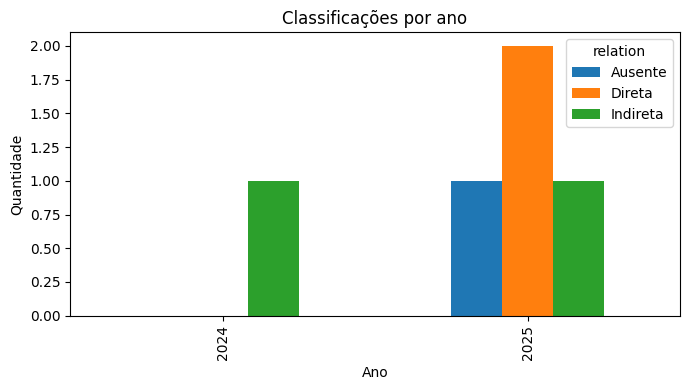

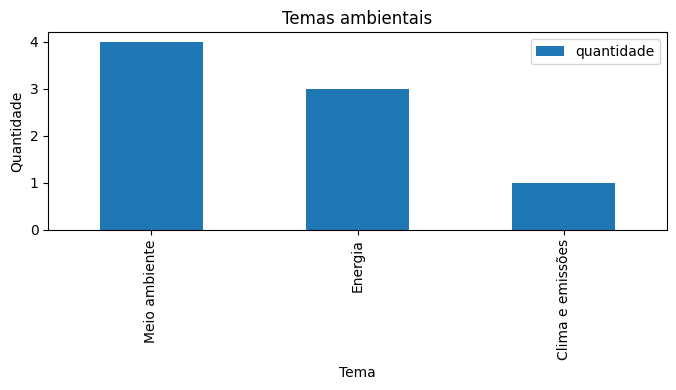

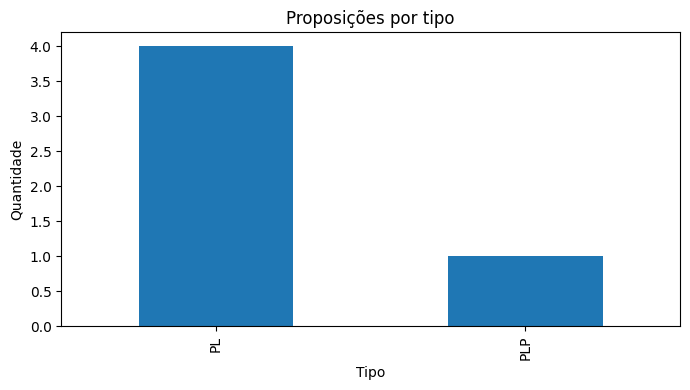

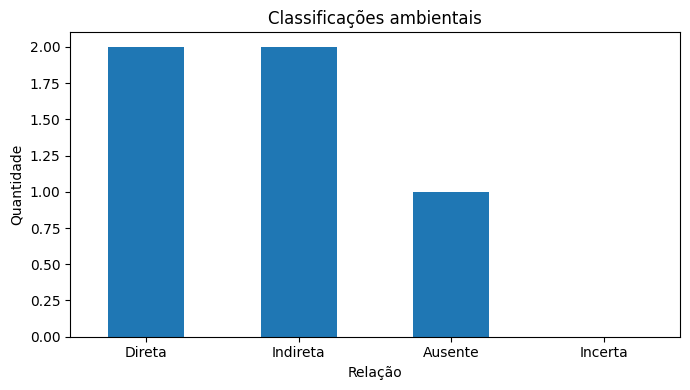

,termo,tfidf
0,inteligência artificial,0.279813
17,tecnologia,0.203017
14,sustentabilidade,0.200000
5,água,0.166176
12,ambiental,0.141421
15,licenciamento,0.141421
13,ambiente,0.138032
10,clima,0.113603
16,incêndio,0.113603


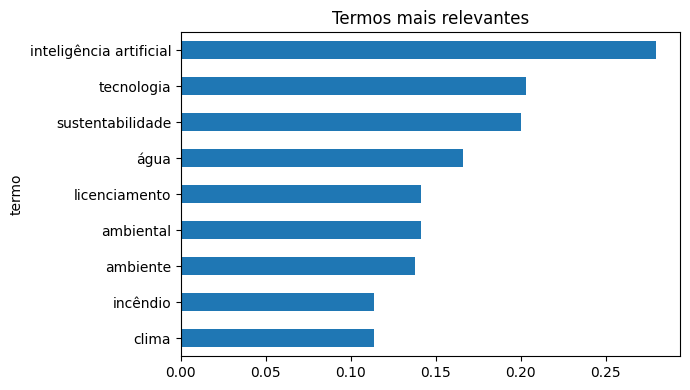

In [9]:
results = pd.read_csv(STAGES / "03_classificacao" / "classificacoes_gpt.csv")
candidates = pd.read_csv(STAGES / "02_limpeza" / "candidatos_gpt.csv")
STAGES.joinpath("05_visualizacao").mkdir(parents=True, exist_ok=True)

results["ano"] = pd.to_datetime(results["date"]).dt.year
por_ano = results.groupby(["ano", "relation"]).size().unstack(fill_value=0)
por_ano.to_csv(STAGES / "05_visualizacao" / "classificacoes_por_ano.csv", encoding="utf-8-sig")
por_ano.plot.bar(figsize=(7, 4), title="Classificações por ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.savefig(STAGES / "05_visualizacao" / "classificacoes_por_ano.png")
plt.show()
plt.close()

temas = results["themes"].fillna("").str.split("; ").explode()
temas = temas[temas != ""]
por_tema = temas.value_counts().rename_axis("tema").to_frame("quantidade")
por_tema.to_csv(STAGES / "05_visualizacao" / "temas_ambientais.csv", encoding="utf-8-sig")
por_tema.plot.bar(figsize=(7, 4), title="Temas ambientais")
plt.xlabel("Tema")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.savefig(STAGES / "05_visualizacao" / "temas_ambientais.png")
plt.show()
plt.close()

por_tipo = results["siglaTipo"].value_counts().rename_axis("tipo").to_frame("quantidade")
por_tipo.to_csv(STAGES / "05_visualizacao" / "proposicoes_por_tipo.csv", encoding="utf-8-sig")
por_tipo.plot.bar(figsize=(7, 4), title="Proposições por tipo", legend=False)
plt.xlabel("Tipo")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.savefig(STAGES / "05_visualizacao" / "proposicoes_por_tipo.png")
plt.show()
plt.close()

counts = results["relation"].value_counts().reindex(["Direta", "Indireta", "Ausente", "Incerta"], fill_value=0)
counts.plot.bar(rot=0, figsize=(7, 4), title="Classificações ambientais")
plt.xlabel("Relação")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.savefig(STAGES / "05_visualizacao" / "classificacoes.png")
plt.show()
plt.close()

termos_do_tema = ["inteligência artificial", "data center", "datacenter", "infraestrutura digital", "computação em nuvem", "água", "hídrica", "energia", "elétrica", "carbono", "clima", "resíduo", "ambiental", "ambiente", "sustentabilidade", "licenciamento", "incêndio", "tecnologia"]
vectorizer = TfidfVectorizer(vocabulary={termo: i for i, termo in enumerate(termos_do_tema)}, ngram_range=(1, 2))
matrix = vectorizer.fit_transform(candidates["ementa"].fillna(""))
terms = pd.DataFrame({"termo": vectorizer.get_feature_names_out(), "tfidf": matrix.mean(axis=0).A1})
terms = terms[terms["tfidf"] > 0].sort_values("tfidf", ascending=False).head(15)
display(terms)
terms.to_csv(STAGES / "05_visualizacao" / "termos_tfidf.csv", index=False, encoding="utf-8-sig")
terms.sort_values("tfidf").plot.barh(x="termo", y="tfidf", legend=False, figsize=(7, 4), title="Termos mais relevantes")
plt.tight_layout()
plt.savefig(STAGES / "05_visualizacao" / "termos_tfidf.png")
plt.show()
plt.close()

## Conclusão
Entre as cinco proposições selecionadas, duas tratam diretamente de impactos ambientais da infraestrutura digital, duas relacionam tecnologia e proteção ambiental de forma indireta e uma menciona IA sem relação ambiental.

Os resultados indicam que o debate legislativo encontrado se concentra em eficiência energética, sustentabilidade e licenciamento de data centers; o consumo de água não aparece como tema direto nas ementas analisadas.

Essa resposta é exploratória e se aplica ao conjunto selecionado por palavras-chave, não a toda a produção legislativa sobre IA e meio ambiente.